100%|██████████| 12000/12000 [00:01<00:00, 8361.12it/s]


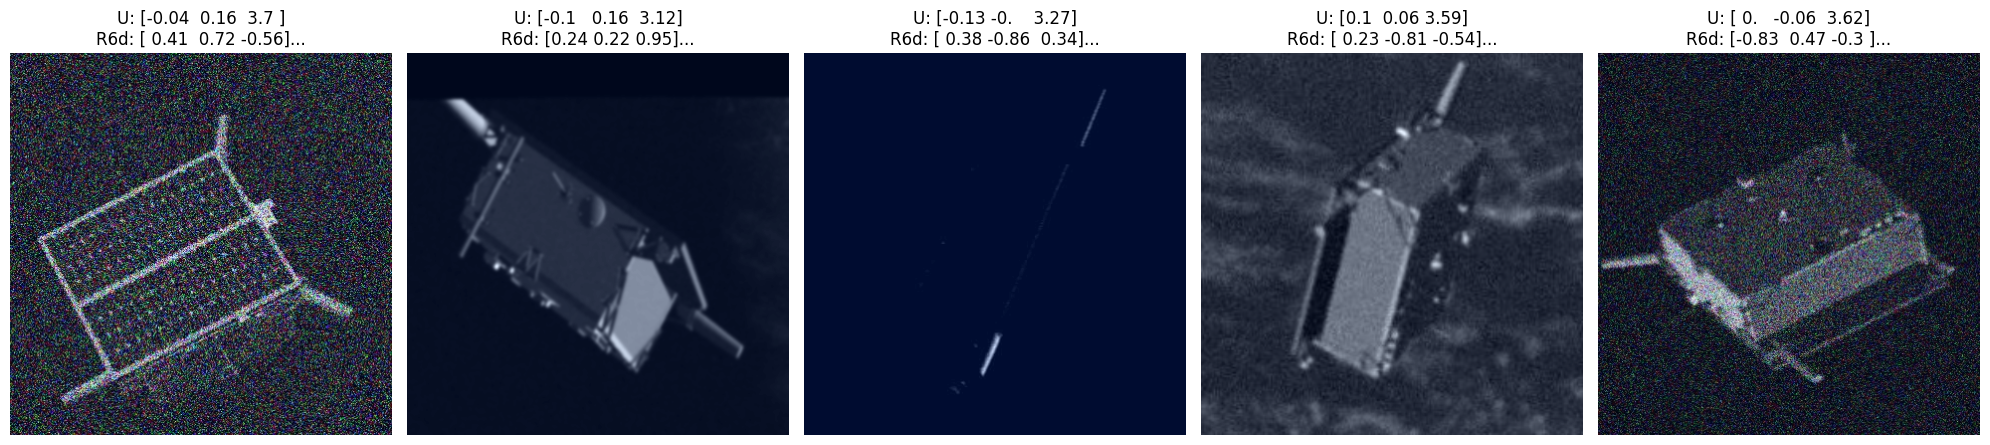

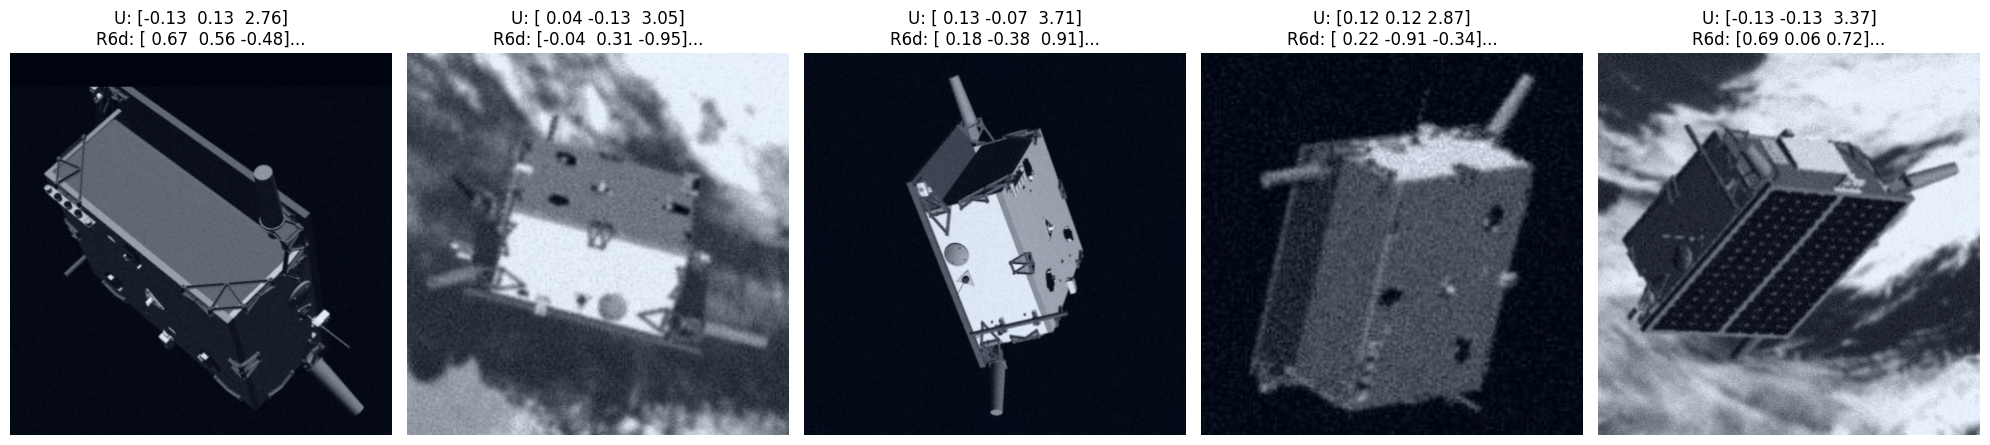

Using device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16_swag-9ac1b537.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16_swag-9ac1b537.pth


100%|██████████| 331M/331M [00:05<00:00, 68.8MB/s]


Layer (type:depth-idx)                             Output Shape              Param #
ViTFastPose                                        [1, 9]                    --
├─VisionTransformer: 1-1                           [1, 9]                    768
│    └─Conv2d: 2-1                                 [1, 768, 24, 24]          590,592
│    └─Encoder: 2-2                                [1, 577, 768]             443,136
│    │    └─Dropout: 3-1                           [1, 577, 768]             --
│    │    └─Sequential: 3-2                        [1, 577, 768]             85,054,464
│    │    └─LayerNorm: 3-3                         [1, 577, 768]             1,536
│    └─Linear: 2-3                                 [1, 9]                    6,921
Total params: 86,097,417
Trainable params: 86,097,417
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 396.90
Input size (MB): 1.77
Forward/backward pass size (MB): 304.87
Params size (MB): 229.22
Estimated Total Size (MB): 535.86
Loaded ch

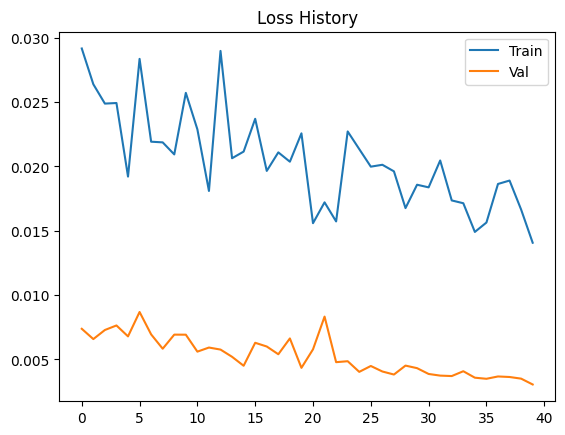

In [1]:
import albumentations as A
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import torch
import torch.backends.cudnn as cudnn
import torch.distributed as dist
import torch.nn.functional as F
import tqdm
from PIL import Image, ImageOps
from scipy.io import loadmat
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from torchvision import models, transforms

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]
    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)
    return cameraMatrix, distCoeffs

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion. """
    q = q/np.linalg.norm(q)
    q0, q1, q2, q3 = q[0], q[1], q[2], q[3]
    dcm = np.zeros((3, 3))
    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2
    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2
    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1
    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1
    return dcm

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    if keypoints.shape[0] != 3 and keypoints.shape[1] == 3:
        keypoints = keypoints.T
    
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))
    
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints)
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:]

    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))
    return points2D

# conversions.py given by Pierre
# This file contains diverse utility functions used in the project


EPS = 1e-8


class Camera:
    """
    Camera class for SPEED/SPEED+ datasets.

    Data class based on UrsoNet's implementation:
    https://github.com/pedropro/UrsoNet/blob/8e59d9b81dd3805aba1d773bd9b44f1a33745b05/speed.py
    Parameters verified with the original SPEED dataset paper:
    https://arxiv.org/pdf/1906.09868
    Also works for SPEED+ dataset, as they share the same camera parameters.
    """

    # Focal length[m]
    fwx = 0.0176
    fwy = 0.0176
    # Image size [pixels]
    width = 1920
    height = 1200
    # Size of the pixels [m / pixel]
    ppx = 5.86e-6
    ppy = ppx

    # Focal length[pixels]
    fx = fwx / ppx
    fy = fwy / ppy

    # Intrinsics matrix
    K = torch.tensor([[fx, 0, width / 2], [0, fy, height / 2], [0, 0, 1]])
    # Inverse of the intrinsics matrix
    K_inv = torch.inverse(K)

    # Centered intrinsics matrix
    K_c = torch.tensor([[fx, 0, 0], [0, fy, 0], [0, 0, 1]])
    # Inverse of the centered intrinsics matrix
    K_c_inv = torch.inverse(K_c)

    # Camera aspect ratio
    aspect_ratio = width / height

    # Pre-computed constants for performance optimization
    width_height_product = width * height
    width_height_over_aspect = width_height_product / aspect_ratio

    # Cache commonly used values for translation computations
    cx = width / 2  # Image center x
    cy = height / 2  # Image center y

_tensor_cache = {}

def _get_cached_tensor(name, device, dtype):
    global _tensor_cache
    key = (name, device, dtype)
    if key not in _tensor_cache:
        if name == "identity_3x3":
            tensor = torch.eye(3, device=device, dtype=dtype)
        elif name == "z_axis":
            tensor = torch.tensor([0.0, 0.0, 1.0], device=device, dtype=dtype)
        else:
            raise ValueError(f"Unknown tensor name: {name}")
        _tensor_cache[key] = tensor
    return _tensor_cache[key]

def quaternion_to_rotation_matrix(quaternions: torch.Tensor) -> torch.Tensor:
    """
    Convert rotations given as quaternions to rotation matrices.
    Args:
        quaternions: quaternions with real part first, as (B, 4) tensor.
    Returns:
        Rotation matrices as (B, 3, 3) tensor.
    """
    r, i, j, k = torch.unbind(quaternions, -1)
    two_s = 2.0 / (quaternions * quaternions).sum(-1)

    o = torch.stack(
        (
            1 - two_s * (j * j + k * k),
            two_s * (i * j - k * r),
            two_s * (i * k + j * r),
            two_s * (i * j + k * r),
            1 - two_s * (i * i + k * k),
            two_s * (j * k - i * r),
            two_s * (i * k - j * r),
            two_s * (j * k + i * r),
            1 - two_s * (i * i + j * j),
        ),
        -1,
    )
    return o.reshape(quaternions.shape[:-1] + (3, 3))

def rotation_matrix_to_quaternion(rotation_matrices: torch.Tensor) -> torch.Tensor:
    """
    Convert rotation matrices to quaternions.
    Args:
        rotation_matrices: (B, 3, 3) tensor
    Returns:
        Quaternions as (B, 4) tensor
    """
    batch_dims = rotation_matrices.shape[:-2]
    m = rotation_matrices.view((-1, 3, 3))
    m00, m01, m02 = m[:, 0, 0], m[:, 0, 1], m[:, 0, 2]
    m10, m11, m12 = m[:, 1, 0], m[:, 1, 1], m[:, 1, 2]
    m20, m21, m22 = m[:, 2, 0], m[:, 2, 1], m[:, 2, 2]

    trace = m00 + m11 + m22
    
    def trace_positive(tensor):
        s = torch.sqrt(trace[tensor] + 1.0) * 2
        w = 0.25 * s
        x = (m21[tensor] - m12[tensor]) / s
        y = (m02[tensor] - m20[tensor]) / s
        z = (m10[tensor] - m01[tensor]) / s
        return w, x, y, z

    def cond_1(tensor):
        s = torch.sqrt(1.0 + m00[tensor] - m11[tensor] - m22[tensor]) * 2
        w = (m21[tensor] - m12[tensor]) / s
        x = 0.25 * s
        y = (m01[tensor] + m10[tensor]) / s
        z = (m02[tensor] + m20[tensor]) / s
        return w, x, y, z

    def cond_2(tensor):
        s = torch.sqrt(1.0 + m11[tensor] - m00[tensor] - m22[tensor]) * 2
        w = (m02[tensor] - m20[tensor]) / s
        x = (m01[tensor] + m10[tensor]) / s
        y = 0.25 * s
        z = (m12[tensor] + m21[tensor]) / s
        return w, x, y, z

    def cond_3(tensor):
        s = torch.sqrt(1.0 + m22[tensor] - m00[tensor] - m11[tensor]) * 2
        w = (m10[tensor] - m01[tensor]) / s
        x = (m02[tensor] + m20[tensor]) / s
        y = (m12[tensor] + m21[tensor]) / s
        z = 0.25 * s
        return w, x, y, z

    kwargs = {"dtype": rotation_matrices.dtype, "device": rotation_matrices.device}
    q = torch.zeros((m.shape[0], 4), **kwargs)
    
    mask_trace_pos = trace > 0
    if mask_trace_pos.any():
        w, x, y, z = trace_positive(mask_trace_pos)
        q[mask_trace_pos] = torch.stack([w, x, y, z], dim=1)
        
    mask_cond_1 = (~mask_trace_pos) & (m00 > m11) & (m00 > m22)
    if mask_cond_1.any():
         w, x, y, z = cond_1(mask_cond_1)
         q[mask_cond_1] = torch.stack([w, x, y, z], dim=1)
         
    mask_cond_2 = (~mask_trace_pos) & (~mask_cond_1) & (m11 > m22)
    if mask_cond_2.any():
         w, x, y, z = cond_2(mask_cond_2)
         q[mask_cond_2] = torch.stack([w, x, y, z], dim=1)

    mask_cond_3 = (~mask_trace_pos) & (~mask_cond_1) & (~mask_cond_2)
    if mask_cond_3.any():
         w, x, y, z = cond_3(mask_cond_3)
         q[mask_cond_3] = torch.stack([w, x, y, z], dim=1)
         
    return q.view(batch_dims + (4,))
    

def _compute_skew_symmetric(axis: torch.Tensor) -> torch.Tensor:
    """Compute skew-symmetric matrix K from axis vector(s)

    Args:
        axis: Shape (..., 3) - batch of axis vectors

    Returns:
        K: Shape (..., 3, 3) - batch of skew-symmetric matrices
    """
    # Handle both single vector and batched inputs
    batch_dims = axis.shape[:-1]
    device, dtype = axis.device, axis.dtype

    K = torch.zeros(*batch_dims, 3, 3, device=device, dtype=dtype)
    K[..., 0, 1] = -axis[..., 2]
    K[..., 0, 2] = axis[..., 1]
    K[..., 1, 0] = axis[..., 2]
    K[..., 1, 2] = -axis[..., 0]
    K[..., 2, 0] = -axis[..., 1]
    K[..., 2, 1] = axis[..., 0]

    return K


def _rodrigues_rotation_matrix(axis: torch.Tensor, angle: torch.Tensor) -> torch.Tensor:
    """Compute rotation matrix using Rodrigues formula

    Args:
        axis: Shape (..., 3) - normalized rotation axis
        angle: Shape (...) - rotation angle

    Returns:
        R: Shape (..., 3, 3) - rotation matrices
    """
    device, dtype = axis.device, axis.dtype
    batch_dims = axis.shape[:-1]

    # Pre-compute trigonometric values
    sin_angle = torch.sin(angle)
    cos_angle = torch.cos(angle)
    one_minus_cos = 1 - cos_angle

    # Get identity matrix
    identity = _get_cached_tensor("identity_3x3", device, dtype)
    if batch_dims:
        identity = identity.unsqueeze(0).expand(*batch_dims, -1, -1)

    # Compute skew-symmetric matrix
    K = _compute_skew_symmetric(axis)
    K_squared = K @ K

    # Rodrigues formula: R = I + sin(θ)K + (1-cos(θ))K²
    if batch_dims:
        sin_angle = sin_angle.view(*batch_dims, 1, 1)
        one_minus_cos = one_minus_cos.view(*batch_dims, 1, 1)

    R = identity + sin_angle * K + one_minus_cos * K_squared

    return R


def _safe_normalize(tensor: torch.Tensor, dim: int = -1, eps: float = EPS) -> torch.Tensor:
    """Safe normalization with epsilon handling"""
    return F.normalize(tensor, p=2, dim=dim, eps=eps)


def _compute_orientation_transform(
    translation: torch.Tensor,
    rotation_quat: torch.Tensor,
    inverse: bool = False,
    no_rotation_compensation: bool = False,
) -> torch.Tensor:
    """
    Unified function for orientation transformations (absolute ↔ apparent).
    Pure batched implementation.

    Args:
        translation: Batch of translation vectors (B, 3)
        rotation_quat: Batch of quaternions (B, 4)
        inverse: If True, computes apparent from absolute (transpose R_rel)
        no_rotation_compensation: Skip rotation compensation

    Returns:
        Batch of transformed quaternions (B, 4)
    """
    if no_rotation_compensation:
        return rotation_quat

    device, dtype = translation.device, translation.dtype
    batch_size = translation.shape[0]

    # Convert quaternions to rotation matrices
    R_input = quaternion_to_rotation_matrix(rotation_quat).to(dtype)

    # Normalize translation vectors
    v_new = _safe_normalize(translation, dim=-1)

    # Get cached z-axis vector and expand for batch
    v_old = _get_cached_tensor("z_axis", device, dtype)
    v_old = v_old.unsqueeze(0).expand(batch_size, -1)

    # Compute dot products and rotation axes
    dot_products = torch.sum(v_old * v_new, dim=-1)
    axes = torch.cross(v_old, v_new, dim=-1)

    # Handle parallel/anti-parallel cases
    axis_norms = torch.norm(axes, dim=-1, keepdim=True)
    parallel_mask = (axis_norms < 1e-6).squeeze(-1)

    # Normalize axes safely
    axes = axes / torch.clamp(axis_norms, min=1e-6)

    # Compute angles
    angles = torch.acos(torch.clamp(dot_products, -1.0, 1.0))

    # Compute rotation matrices using Rodrigues formula
    R_rel = _rodrigues_rotation_matrix(axes, angles)

    # Handle special cases for parallel vectors
    identity = _get_cached_tensor("identity_3x3", device, dtype)
    antiparallel_rot = torch.diag(torch.tensor([1.0, -1.0, -1.0], device=device, dtype=dtype))

    identity = identity.unsqueeze(0).expand(batch_size, -1, -1)
    antiparallel_rot = antiparallel_rot.unsqueeze(0).expand(batch_size, -1, -1)

    positive_parallel = parallel_mask & (dot_products > 0)
    negative_parallel = parallel_mask & (dot_products <= 0)

    R_rel = torch.where(positive_parallel.unsqueeze(-1).unsqueeze(-1), identity, R_rel)
    R_rel = torch.where(negative_parallel.unsqueeze(-1).unsqueeze(-1), antiparallel_rot, R_rel)

    # Apply transformation (normal or inverse)
    if inverse:
        R_result = torch.transpose(R_rel, -2, -1) @ R_input  # Transpose for inverse
    else:
        R_result = R_rel @ R_input

    return rotation_matrix_to_quaternion(R_result)


def _orthogonalize_svd(matrix: torch.Tensor) -> torch.Tensor:
    """
    Symmetric orthogonalization using SVD.
    Finds the closest orthogonal matrix R to input M: R = UV^T where M = USV^T

    Args:
        matrix (torch.Tensor): (B, 3, 2) - two column vectors forming partial rotation matrix

    Returns:
        torch.Tensor: (B, 3, 2) - orthogonalized column vectors
    """
    # Normalize columns first to improve numerical stability
    # This prevents SVD gradient issues when input has very large/small singular values
    matrix = F.normalize(matrix, p=2, dim=1)

    U, S, Vh = torch.linalg.svd(matrix, full_matrices=False)
    return U @ Vh


def _orthogonalize_newton_schulz(matrix: torch.Tensor, num_iters: int = 5) -> torch.Tensor:
    """
    Newton-Schulz iteration for orthogonalization.
    Iteratively converges: X_{k+1} = 0.5 * X_k * (3I - X_k^T X_k)

    The iteration converges when the singular values of the input are in (0, sqrt(3)).
    To ensure convergence, we first normalize columns to have unit norm.

    Args:
        matrix (torch.Tensor): (B, 3, 2) - two column vectors
        num_iters (int): number of iterations (default 5)

    Returns:
        torch.Tensor: (B, 3, 2) - orthogonalized column vectors
    """
    # Normalize columns first to ensure convergence (singular values close to 1)
    X = F.normalize(matrix, p=2, dim=1)
    Id = torch.eye(2, device=X.device, dtype=X.dtype)
    for _ in range(num_iters):
        X = 0.5 * X @ (3 * Id - X.transpose(-1, -2) @ X)
    return X


def get_rotation_matrix(x: torch.Tensor, orthogonalization: str = "gram_schmidt") -> torch.Tensor:
    """
    Orthogonalize input vectors and compute rotation matrix in SO(3).
    Pure batched implementation.

    Args:
        x (torch.Tensor): Batch of 6D vectors (B, 6) containing [r1, r2] vectors
        orthogonalization (str): Method to use - "gram_schmidt", "svd", or "newton_schulz"

    Returns:
        torch.Tensor: Batch of rotation matrices (B, 3, 3)
    """
    # Split input efficiently
    v1, v2 = x[:, :3], x[:, 3:]

    if orthogonalization == "gram_schmidt":
        # Normalize v1
        v1 = _safe_normalize(v1, dim=1)

        # Use Gram-Schmidt to compute v2 (optimized dot product computation)
        v2_dot_v1 = torch.sum(v2 * v1, dim=1, keepdim=True)
        v2 = v2 - v2_dot_v1 * v1
        v2 = _safe_normalize(v2, dim=1)
    else:
        # Stack vectors as columns: (B, 3, 2)
        matrix = torch.stack([v1, v2], dim=2)

        if orthogonalization == "svd":
            matrix = _orthogonalize_svd(matrix)
        elif orthogonalization == "newton_schulz":
            matrix = _orthogonalize_newton_schulz(matrix)
        else:
            raise ValueError(f"Unknown orthogonalization method: {orthogonalization}")

        v1, v2 = matrix[:, :, 0], matrix[:, :, 1]

    # Compute v3 as cross product of v1 and v2
    v3 = torch.cross(v1, v2, dim=1)

    # Stack the vectors to form the rotation matrix (memory efficient)
    return torch.stack([v1, v2, v3], dim=2)


def rotation_matrix_to_6d(rotation_matrices: torch.Tensor) -> torch.Tensor:
    """
    Convert rotation matrices to 6D representation (first two columns).
    Pure batched implementation.

    Args:
        rotation_matrices (torch.Tensor): Batch of rotation matrices (B, 3, 3)

    Returns:
        torch.Tensor: Batch of 6D vectors (B, 6)
    """
    # Extract first two columns of the rotation matrix
    v1 = rotation_matrices[:, :, 0]  # Shape: (B, 3)
    v2 = rotation_matrices[:, :, 1]  # Shape: (B, 3)

    # Concatenate to form 6D representation
    return torch.cat([v1, v2], dim=1)  # Shape: (B, 6)


def translation_to_bbox_relative_translation(
    translation: torch.Tensor,
    bbox: torch.Tensor,
    camera: Camera,
) -> torch.Tensor:
    """
    Transform translation vectors to relative translation vectors based on bounding boxes and camera parameters.
    Pure batched implementation.
    Inspired by: https://openaccess.thecvf.com/content_ICCV_2019/papers/Li_CDPN_Coordinates-Based_Disentangled_Pose_Network_for_Real-Time_RGB-Based_6-DoF_Object_ICCV_2019_paper.pdf

    Args:
        translation: torch.Tensor - Batch of translation vectors (B, 3)
        bbox: torch.Tensor - Batch of bboxes (B, 4) containing [x1, y1, x2, y2]
        camera: Camera object with intrinsic parameters

    Returns:
        torch.Tensor - Batch of relative translations (B, 3)
    """
    # Compute bbox dimensions and centers in one go
    bbox_dims = bbox[:, 2:] - bbox[:, :2]  # [w, h] Shape: (B, 2)
    w, h = bbox_dims[:, 0], bbox_dims[:, 1]  # Shape: (B,) each
    bbox_centers = bbox[:, :2] + bbox_dims * 0.5  # Shape: (B, 2)
    bbox_center_x, bbox_center_y = bbox_centers[:, 0], bbox_centers[:, 1]

    # Cache camera parameters
    cx, cy, fx, fy = camera.cx, camera.cy, camera.fx, camera.fy

    # Cache translation components
    tx, ty, tz = translation[:, 0], translation[:, 1], translation[:, 2]

    # Use least squares solution for avg_ratio computation
    avg_ratio = 0.5 * ((w * camera.aspect_ratio) / camera.width + h / camera.height)
    new_target_z = tz * avg_ratio

    # Vectorized target computation
    inv_tz = 1.0 / tz
    new_target_x = (tx * fx * inv_tz + cx - bbox_center_x) / w
    new_target_y = (ty * fy * inv_tz + cy - bbox_center_y) / h

    # Use torch.stack for better performance than individual assignments
    return torch.stack([new_target_x, new_target_y, new_target_z], dim=1)


def bbox_relative_translation_to_translation(
    bbox_relative_translation: torch.Tensor,
    bbox: torch.Tensor,
    camera: Camera,
) -> torch.Tensor:
    """
    Transform bbox relative translation vectors to absolute translations based on bounding boxes and camera parameters.
    Pure batched implementation.
    Inspired by: https://openaccess.thecvf.com/content_ICCV_2019/papers/Li_CDPN_Coordinates-Based_Disentangled_Pose_Network_for_Real-Time_RGB-Based_6-DoF_Object_ICCV_2019_paper.pdf

    Args:
        bbox_relative_translation: torch.Tensor - Batch of relative translations (B, 3)
        bbox: torch.Tensor - Batch of bboxes (B, 4) containing [x1, y1, x2, y2]
        camera: Camera object with intrinsic parameters

    Returns:
        torch.Tensor - Batch of absolute translations (B, 3)
    """
    # Compute bbox dimensions and centers efficiently
    bbox_dims = bbox[:, 2:] - bbox[:, :2]  # [w, h] Shape: (B, 2)
    w, h = bbox_dims[:, 0], bbox_dims[:, 1]  # Shape: (B,) each
    bbox_centers = bbox[:, :2] + bbox_dims * 0.5  # Shape: (B, 2)
    bbox_center_x, bbox_center_y = bbox_centers[:, 0], bbox_centers[:, 1]

    # Cache camera parameters
    cx, cy, fx, fy = camera.cx, camera.cy, camera.fx, camera.fy

    # Cache relative translation components
    rel_tx, rel_ty, rel_tz = (
        bbox_relative_translation[:, 0],
        bbox_relative_translation[:, 1],
        bbox_relative_translation[:, 2],
    )

    # Compute translation_z using least squares solution
    avg_ratio = 0.5 * ((w * camera.aspect_ratio) / camera.width + h / camera.height)
    translation_z = rel_tz / avg_ratio

    # Compute A and B coefficients
    A = (rel_tx * w - cx + bbox_center_x) / fx
    B = (rel_ty * h - cy + bbox_center_y) / fy

    # Compute x and y translations
    translation_x = A * translation_z
    translation_y = B * translation_z

    return torch.stack([translation_x, translation_y, translation_z], dim=1)
    
    
def get_absolute_orientation(
    translation: torch.Tensor, rotation_quat: torch.Tensor, no_rotation_compensation: bool = False
) -> torch.Tensor:
    """
    Convert apparent rotations to absolute rotations (centered on image).
    Pure batched implementation.

    Args:
        translation (torch.Tensor): Batch of translation vectors (B, 3)
        rotation_quat (torch.Tensor): Batch of quaternions (B, 4)
        no_rotation_compensation: bool to disable rotation compensation

    Returns:
        torch.Tensor: Batch of centered rotations as quaternions (B, 4)
    """
    return _compute_orientation_transform(
        translation,
        rotation_quat,
        inverse=False,
        no_rotation_compensation=no_rotation_compensation,
    )


def get_apparent_orientation(
    translation: torch.Tensor,
    centered_rotation_quat: torch.Tensor,
    no_rotation_compensation: bool = False,
) -> torch.Tensor:
    """
    Convert absolute rotations to apparent rotations (perturbed by translation).
    Pure batched implementation.

    Args:
        translation (torch.Tensor): Batch of translation vectors (B, 3)
        centered_rotation_quat (torch.Tensor): Batch of quaternions (B, 4)
        no_rotation_compensation: bool to disable rotation compensation

    Returns:
        torch.Tensor: Batch of apparent rotations as quaternions (B, 4)
    """
    return _compute_orientation_transform(
        translation,
        centered_rotation_quat,
        inverse=True,
        no_rotation_compensation=no_rotation_compensation,
    )


class Speed(Dataset):
    def __init__(self, images_dir, json_dir,is_augment=True, transform=None):
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.transform = transform
        self.augment = is_augment 
        self.imagesList = []
        self.BBoxList = []
        self.qList = []
        self.tList = []
        self.camera = Camera()
        self.keypts3d = None
        self.cameraMatrix = None
        self.distCoeffs = None

        # Pixel-level augmentations
        self.pixel_augment = A.Compose([
            A.OneOf([
                A.RandomBrightnessContrast(p=1.0),
                A.HueSaturationValue(p=1.0),
                A.RGBShift(p=1.0),
            ], p=0.5),
            A.OneOf([
                A.MotionBlur(p=1.0),
                A.GaussianBlur(p=1.0),
                A.GaussNoise(p=1.0),
            ], p=0.5),
            A.ImageCompression(quality_range=(85, 100), p=0.5),
        ], p=1.0) # Apply the pipeline elements stochastically


        # Placeholder loading logic
        if not os.path.exists(json_dir):
            print(f"Warning: JSON file {json_dir} not found. Creating empty dataset.")
            return

        # Load intrinsics and 3D points
        try:
             # Assuming these paths are fixed or relative to project
             self.keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat')
             self.cameraMatrix, self.distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')
        except:
             # Basic mock
             self.keypts3d = np.zeros((11, 3), dtype=np.float32)
             self.cameraMatrix, self.distCoeffs = np.eye(3, dtype=np.float32), np.zeros(5, dtype=np.float32)

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }
            cnt = 0

            if os.path.exists(self.images_dir):
                file_list = sorted(os.listdir(self.images_dir))
            else:
                file_list = []

            for filename in tqdm.tqdm(file_list):
                if filename not in lookup: continue
                
                # Image path
                self.imagesList.append(os.path.join(self.images_dir, filename))
                
                # Parse q and t
                q = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                t = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)
                
                self.qList.append(torch.from_numpy(q))
                self.tList.append(torch.from_numpy(t))
                
                # Project keypoints to get BBox
                keypts2d = project_keypoints(q, t, self.cameraMatrix, self.distCoeffs, self.keypts3d)
                
                # Use helper to get padded and squared bbox
                bbox = self._get_bbox_from_keypoints(keypts2d, self.camera.width, self.camera.height)
                self.BBoxList.append(bbox)

                cnt += 1
                # if cnt > 100: break 

    def __len__(self):
        return len(self.imagesList)

    def _safe_crop(self, image, bbox):
        # Unpack and ensure we aren't modifying the original tensor/array
        xmin, ymin, xmax, ymax = bbox.tolist() if torch.is_tensor(bbox) else bbox
        
        # 1. Calculate PADDING needs
        # If xmin is -5.5, we need ceil(5.5) = 6 pixels of padding
        pad_left = max(0, int(math.ceil(-xmin)))
        pad_top = max(0, int(math.ceil(-ymin)))
        
        # If xmax is 105.5 and width is 100, we need ceil(5.5) = 6 pixels
        pad_right = max(0, int(math.ceil(xmax - image.width)))
        pad_bottom = max(0, int(math.ceil(ymax - image.height)))
        
        # 2. Apply Padding (only if needed)
        if pad_left > 0 or pad_top > 0 or pad_right > 0 or pad_bottom > 0:
            # fill=0 is black, which is standard for space backgrounds
            image = ImageOps.expand(image, border=(pad_left, pad_top, pad_right, pad_bottom), fill=0)
        
        # 3. Adjust Crop Coordinates
        # Since we added pixels to the left/top, the coordinate system shifts
        # We round to nearest integer for the final PIL crop
        crop_xmin = int(xmin + pad_left)
        crop_ymin = int(ymin + pad_top)
        crop_xmax = int(xmax + pad_left)
        crop_ymax = int(ymax + pad_top)
        
        return image.crop((crop_xmin, crop_ymin, crop_xmax, crop_ymax))

    def _get_bbox_from_keypoints(self, keypts2d, img_w, img_h):
        # Calculate tight width/height from keypoints
        xmin, xmax = np.min(keypts2d[0]), np.max(keypts2d[0])
        ymin, ymax = np.min(keypts2d[1]), np.max(keypts2d[1])
        
        w_tight = xmax - xmin
        h_tight = ymax - ymin
        
        # Add a Margin: Expand the box by a percentage (e.g., 15%) to account for parts of the satellite not covered by keypoints.
        pad_w = w_tight * 0.15
        pad_h = h_tight * 0.15
        
        # Apply padding to coordinates
        xmin -= pad_w / 2
        xmax += pad_w / 2
        ymin -= pad_h / 2
        ymax += pad_h / 2
        
        # Make it Square (Optional but Recommended)
        # Expanding the shorter side to match the longer side creates a square BBox, which naturally adds padding and prevents distortion.
        w_new = xmax - xmin
        h_new = ymax - ymin
        max_dim = max(w_new, h_new)
        
        center_x = (xmin + xmax) / 2
        center_y = (ymin + ymax) / 2
        
        xmin = center_x - max_dim / 2
        xmax = center_x + max_dim / 2
        ymin = center_y - max_dim / 2
        ymax = center_y + max_dim / 2
        
        # Clip to image boundaries - REMOVED to preserve centering
        # xmin = max(0, xmin)
        # ymin = max(0, ymin)
        # xmax = min(img_w, xmax)
        # ymax = min(img_h, ymax)
        
        return torch.tensor([xmin, ymin, xmax, ymax], dtype=torch.float32)

    def _augment_spatial(self, image, q, t):
        if np.random.rand() > 0.5:
            return image, q, t

        # Choose rotation range: [-20, 20] or [160, 200]
        if np.random.rand() < 0.5:
            angle_deg = np.random.uniform(-20, 20)
        else:
            angle_deg = np.random.uniform(160, 200)
            
        angle_rad = np.deg2rad(angle_deg)
        
        # Do rotation using Pierre's functions (vectorized)
        # Convert angle to axis-angle or quaternion representation
        # R_z implementation in torch:
        c, s = np.cos(angle_rad), np.sin(angle_rad)
        R_z = torch.tensor([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=torch.float32)

        # Convert Input Quaternion to Rotation Matrix
        # Note: inputs are single items, so we unsqueeze to make them batch size 1
        R_orig = quaternion_to_rotation_matrix(q.unsqueeze(0)).squeeze(0)
        
        R_new = R_z @ R_orig
        T_new = R_z @ t
        
        q_new = rotation_matrix_to_quaternion(R_new.unsqueeze(0)).squeeze(0)
        
        # Image rotation remains PIL
        image_rotated = image.rotate(-angle_deg, resample=Image.BILINEAR, expand=False)
        
        return image_rotated, q_new, T_new

    def _augment_bbox(self, bbox, width, height):
        # bbox: [xmin, ymin, xmax, ymax]
        xmin, ymin, xmax, ymax = bbox
        w_box = xmax - xmin
        h_box = ymax - ymin
        
        # Randomly expand/contract up to 10%
        scale_x = np.random.uniform(-0.1, 0.1)
        scale_y = np.random.uniform(-0.1, 0.1)
        scale_w = np.random.uniform(-0.1, 0.1)
        scale_h = np.random.uniform(-0.1, 0.1)
        
        # Perturb boundaries
        xmin -= w_box * scale_x
        ymin -= h_box * scale_y
        xmax += w_box * scale_w
        ymax += h_box * scale_h
        
        # Clip to image - REMOVED to preserve centering
        # xmin = max(0, xmin)
        # ymin = max(0, ymin)
        # xmax = min(width, xmax)
        # ymax = min(height, ymax)
        
        # Validate
        if xmax <= xmin or ymax <= ymin:
             return bbox # Return original if invalid
             
        return torch.tensor([xmin, ymin, xmax, ymax], dtype=torch.float32)

    def __getitem__(self, idx):
        image_path = self.imagesList[idx]
        image = Image.open(image_path).convert('RGB')
        
        bbox = self.BBoxList[idx] # xmin, ymin, xmax, ymax
        q_vbs2tango = self.qList[idx]
        r_Vo2To_vbs_true = self.tList[idx]
        
        # --- Augmentation Start ---
        if self.augment:
            # 1. Spatial Augmentation
            image, q_vbs2tango, r_Vo2To_vbs_true = self._augment_spatial(image, q_vbs2tango, r_Vo2To_vbs_true)
            
            # Recalculate BBox from new pose
            keypts2d = project_keypoints(q_vbs2tango.numpy(), r_Vo2To_vbs_true.numpy(), self.cameraMatrix, self.distCoeffs, self.keypts3d)
            
            # Apply margin similar to init using the helper
            bbox = self._get_bbox_from_keypoints(keypts2d, image.width, image.height)
            
            # 2. Bounding Box Augmentation
            bbox = self._augment_bbox(bbox, image.width, image.height)
            
        # --- Augmentation End ---
        
        # 1. Crop and Resize
        xmin, ymin, xmax, ymax = bbox.tolist()
        
        w = xmax - xmin
        h = ymax - ymin
        if w <= 0 or h <= 0:
            xmin, ymin, xmax, ymax = 0, 0, 384, 384
        
        # Ensure crop coordinates are valid - Handled by _safe_crop
        train_w, train_h = 384, 384
        
        image_crop = self._safe_crop(image, (xmin, ymin, xmax, ymax))
        image_crop = image_crop.resize((train_w, train_h), Image.BILINEAR)

        # 3. Pixel-Level Augmentation (on cropped image)
        if self.augment:
             img_np = np.array(image_crop)
             augmented = self.pixel_augment(image=img_np)
             image_crop = Image.fromarray(augmented['image'])

        # 2. Transform
        if self.transform:
            image_crop = self.transform(image_crop)
            
        # 3. Compute Targets (Batched helpers need unsqueeze)
        bbox_uns = bbox.unsqueeze(0) # [1, 4]
        q_uns = q_vbs2tango.unsqueeze(0) # [1, 4]
        t_uns = r_Vo2To_vbs_true.unsqueeze(0) # [1, 3]
        
        # Translation Target U: [Ux, Uy, Uz]
        target_U_batch = translation_to_bbox_relative_translation(t_uns, bbox_uns, self.camera)
        target_U = target_U_batch.squeeze(0)
        
        # Rotation Target R': Apparent rotation
        q_apparent_batch = get_apparent_orientation(t_uns, q_uns)
        target_R_matrix_batch = quaternion_to_rotation_matrix(q_apparent_batch)
        target_R_6d_batch = rotation_matrix_to_6d(target_R_matrix_batch)
        target_R_6d = target_R_6d_batch.squeeze(0)
        
        return image_crop, target_U, target_R_6d

def plot_dataset_samples(dataset, n=5):

    fig, axes = plt.subplots(1, n, figsize=(20, 5))
    for i in range(n):
        image, target_U, target_R_6d = dataset[i]
        
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).numpy()
            # Simple denormalization if needed or clipping for visualization
            image = (image - image.min()) / (image.max() - image.min() + 1e-5)
            
        axes[i].imshow(image)
        axes[i].set_title(f"U: {target_U.numpy().round(2)}\nR6d: {target_R_6d.numpy()[:3].round(2)}...")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
train_dataset = Speed(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', transform=transform, is_augment=True)
val_dataset = Speed(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', transform=transform, is_augment=False)

dataset_size = len(train_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

seed = 42                                   
indices = list(range(dataset_size))
random.Random(seed).shuffle(indices) 
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_data = torch.utils.data.Subset(train_dataset, train_indices)
val_data = torch.utils.data.Subset(val_dataset, val_indices)

plot_dataset_samples(train_data)

plot_dataset_samples(val_data)

class ViTFastPose(nn.Module):
    def __init__(self):
        super().__init__()
        try:
            weights = models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
        except AttributeError:
             print("Warning: SWAG weights not found, using DEFAULT.")
             weights = models.ViT_B_16_Weights.DEFAULT
             
        self.backbone = models.vit_b_16(weights=weights)
        
        # We replace the 'heads' layer (which defaults to the classification head) with our regression head.
        # The output dimension is 9: 3 for translation (target_U) + 6 for rotation (target_R_6d).
        self.backbone.heads = nn.Linear(self.backbone.hidden_dim, 9)
        
    def forward(self, x):
        # The torchvision ViT model automatically handles the CLS token and passing it through the head.
        # Input: [B, 3, H, W] -> Output: [B, 9]
        return self.backbone(x)

def save_checkpoint(states, is_best, output_dir, filename='checkpoint.pth'):
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    torch.save(states, os.path.join(output_dir, filename))
    if is_best and 'state_dict' in states:
        torch.save(states['best_state_dict'], os.path.join(output_dir, 'model_best.pth'))



def zeropower_via_newtonschulz5(G, steps: int):
    """
    Newton-Schulz iteration to compute the zeroth power / orthogonalization of G. We opt to use a
    quintic iteration whose coefficients are selected to maximize the slope at zero. For the purpose
    of minimizing steps, it turns out to be empirically effective to keep increasing the slope at
    zero even beyond the point where the iteration no longer converges all the way to one everywhere
    on the interval. This iteration therefore does not produce UV^T but rather something like US'V^T
    where S' is diagonal with S_{ii}' ~ Uniform(0.5, 1.5), which turns out not to hurt model
    performance at all relative to UV^T, where USV^T = G is the SVD.
    """
    assert G.ndim >= 2 # batched Muon implementation by @scottjmaddox, and put into practice in the record by @YouJiacheng
    a, b, c = (3.4445, -4.7750,  2.0315)
    if G.is_cuda:
        X = G.bfloat16()
    else:
        X = G.float() # Force float32 on CPU
    if G.size(-2) > G.size(-1):
        X = X.mT

    # Ensure spectral norm is at most 1
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    # Perform the NS iterations
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A # quintic computation strategy adapted from suggestion by @jxbz, @leloykun, and @YouJiacheng
        X = a * X + B @ X

    if G.size(-2) > G.size(-1):
        X = X.mT
    return X

def muon_update(grad, momentum, beta=0.95, ns_steps=5, nesterov=True):
    momentum.lerp_(grad, 1 - beta)
    update = grad.lerp_(momentum, beta) if nesterov else momentum
    if update.ndim == 4: # for the case of conv filters
        update = update.view(len(update), -1)
    update = zeropower_via_newtonschulz5(update, steps=ns_steps)
    update *= max(1, grad.size(-2) / grad.size(-1))**0.5
    return update

class Muon(torch.optim.Optimizer):
    """
    Muon - MomentUm Orthogonalized by Newton-schulz

    https://kellerjordan.github.io/posts/muon/

    Muon internally runs standard SGD-momentum, and then performs an orthogonalization post-
    processing step, in which each 2D parameter's update is replaced with the nearest orthogonal
    matrix. For efficient orthogonalization we use a Newton-Schulz iteration, which has the
    advantage that it can be stably run in bfloat16 on the GPU.

    Muon should only be used for hidden weight layers. The input embedding, final output layer,
    and any internal gains or biases should be optimized using a standard method such as AdamW.
    Hidden convolutional weights can be trained using Muon by viewing them as 2D and then
    collapsing their last 3 dimensions.

    Arguments:
        lr: The learning rate, in units of spectral norm per update.
        weight_decay: The AdamW-style weight decay.
        momentum: The momentum. A value of 0.95 here is usually fine.
    """
    def __init__(self, params, lr=0.02, weight_decay=0, momentum=0.95):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum)
        
        # Handle generator or list of params
        if not isinstance(params, list):
            params = list(params)
            
        assert isinstance(params, list) and len(params) >= 1 and isinstance(params[0], torch.nn.Parameter)
        params = sorted(params, key=lambda x: x.size(), reverse=True)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):

        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            params = group["params"]
            # Handle distributed padding if needed, but for single GPU/simple use we can simplify or keep it.
            # keeping it robust as per original implementation
            params_pad = params 
            if dist.is_initialized():
                 params_pad = params + [torch.empty_like(params[-1])] * (dist.get_world_size() - len(params) % dist.get_world_size())
            
            # Simple single process loop if not distributed
            if not dist.is_initialized():
                for p in params:
                    if p.grad is None: continue
                    
                    state = self.state[p]
                    if len(state) == 0:
                        state["momentum_buffer"] = torch.zeros_like(p)
                    
                    # Muon update
                    update = muon_update(p.grad, state["momentum_buffer"], beta=group["momentum"])
                    
                    # Apply weight decay and update
                    if group["weight_decay"] > 0:
                        p.mul_(1 - group["lr"] * group["weight_decay"])
                        
                    p.add_(update.reshape(p.shape), alpha=-group["lr"])
            else:
                # Original distributed logic
                 for base_i in range(len(params))[::dist.get_world_size()]:
                    if base_i + dist.get_rank() < len(params):
                        p = params[base_i + dist.get_rank()]
                        if p.grad is None:
                            # continue
                            p.grad = torch.zeros_like(p)  # Force synchronization
                        state = self.state[p]
                        if len(state) == 0:
                            state["momentum_buffer"] = torch.zeros_like(p)
                        update = muon_update(p.grad, state["momentum_buffer"], beta=group["momentum"])
                        p.mul_(1 - group["lr"] * group["weight_decay"])
                        p.add_(update.reshape(p.shape), alpha=-group["lr"])
                    dist.all_gather(params_pad[base_i:base_i + dist.get_world_size()], params_pad[base_i + dist.get_rank()])

        return loss


def compute_losses(pred_9d, target_U, target_R_6d):
    """
    Compute rotation and translation losses.
    pred_9d: [B, 9] -> (pred_U [B, 3], pred_R_6d [B, 6])
    target_U: [B, 3] (Normalized crop-space targets)
    target_R_6d: [B, 6] (First two columns of apparent rotation matrix)
    """
    pred_U = pred_9d[:, :3]
    pred_R_6d = pred_9d[:, 3:]
    
    # Translation Loss: L_trans = || U_pred - U_gt ||^2
    # Note: The paper says ||...||^2 which implies squared Euclidean norm.
    loss_trans = F.mse_loss(pred_U, target_U, reduction='none').sum(dim=1).mean()
    
    # Rotation Loss: L_rot = || R'_pred,1:2 - R'_gt,1:2 ||_F^2
    # This is effectively relative Frobenius error on the 6D representation.
    loss_rot = F.mse_loss(pred_R_6d, target_R_6d, reduction='none').sum(dim=1).mean()
    
    loss_total = loss_rot + loss_trans
    return loss_total, loss_rot, loss_trans

def train_loop(train_dataloader, val_dataloader, model, optimizer, scheduler, device, epoch):
    model.train()
    loss_tot = 0
    num_batches = len(train_dataloader)
    batch_size = train_dataloader.batch_size
    train_size = len(train_dataloader.dataset)
    
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    
    # Train
    for batch, (X, target_U, target_R_6d) in enumerate(train_dataloader):
        X = X.to(device)
        target_U = target_U.to(device)
        target_R_6d = target_R_6d.to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            pred_9d = model(X)
            loss, l_rot, l_trans = compute_losses(pred_9d, target_U, target_R_6d)
        
        scaler.scale(loss).backward()
        
        if hasattr(optimizer, 'opts'):
            for opt in optimizer.opts:
                scaler.step(opt)
        else:
            scaler.step(optimizer)
            
        scaler.update()
        
        loss_tot += loss.item()

        current=batch*batch_size+len(X)
        
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>10.9f} (Rot: {l_rot.item():.6f}, Trans: {l_trans.item():.6f})  [{current:>5d}/{train_size:>5d}]                           ", end="")
            
    loss_avg = loss_tot / num_batches
    
    model.eval()
    val_loss_tot = 0
    with torch.no_grad():   
        for val_batch, (X, target_U, target_R_6d) in enumerate(val_dataloader):
            X = X.to(device)
            target_U = target_U.to(device)
            target_R_6d = target_R_6d.to(device)
            
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                pred_9d = model(X)
                loss, _, _ = compute_losses(pred_9d, target_U, target_R_6d)
            
            val_loss_tot += loss.item()
            current = val_batch * batch_size + len(X)
            print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>10.9f} - Validation loss: {loss:>10.9f}  [{current:>5d}/{len(val_dataloader.dataset):>5d}]                           ", end="")
            
    val_loss = val_loss_tot / len(val_dataloader) if len(val_dataloader) > 0 else 0

    print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>10.9f} - Validation loss: {val_loss:>10.9f}                                                    ")
    print(end='')
    return loss_avg, val_loss


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
cudnn.benchmark = True

batch_size = 8 
use_pin_memory = torch.cuda.is_available()

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=use_pin_memory)
val_dataloader = DataLoader(val_data, batch_size, shuffle=False, num_workers=4, pin_memory=use_pin_memory)
    
input_dir = '/kaggle/input/fastpose'
output_dir = '/kaggle/working/'

model = ViTFastPose().to(device)
print(summary(model, (1, 3, 384, 384)))

muon_params = []
adamw_params = []
for name, p in model.named_parameters():
    if p.requires_grad:
            if p.ndim >= 2 and 'head' not in name and 'cls_token' not in name and 'pos_embed' not in name:
                muon_params.append(p)
            else:
                adamw_params.append(p)
                
optimizer_muon = Muon(muon_params, lr=1e-4, weight_decay=0.0) 
optimizer_adamw = optim.AdamW(adamw_params, lr=1e-4, weight_decay=0.0) 


scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_adamw, T_0=10, T_mult=2, eta_min=1e-6)

class CombinedOptimizer:
    def __init__(self, opts):
        self.opts = opts
    def zero_grad(self):
        for o in self.opts: o.zero_grad()
    def step(self):
        for o in self.opts: o.step()
    def state_dict(self):
        return [o.state_dict() for o in self.opts]
    def load_state_dict(self, states):
        for o, s in zip(self.opts, states): o.load_state_dict(s)
        
optimizer = CombinedOptimizer([optimizer_muon, optimizer_adamw])

best_perf = float('inf')
begin_epoch = 0
checkpoint_file = os.path.join(input_dir, 'checkpoint.pth')

if os.path.isfile(checkpoint_file):
    checkpoint = torch.load(checkpoint_file, weights_only=False, map_location=device) 
    begin_epoch = checkpoint['epoch']
    best_perf = checkpoint.get('perf', float('inf'))
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    if 'scheduler' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler'])
    else:
        print(f"Scheduler state not found. Catching up scheduler for {begin_epoch} epochs...")
        for _ in range(begin_epoch):
            scheduler.step()
    print(f"Loaded checkpoint : {checkpoint_file} at epoch {begin_epoch}")

num_epochs = 70
loss_history = {'train': [], 'val': []}

start_epoch = begin_epoch
print(f"Starting training for Epoch: {start_epoch+1}")

for t in range(start_epoch, num_epochs):
    train_loss, val_loss = train_loop(train_dataloader, val_dataloader, model, optimizer,scheduler, device, t)
    scheduler.step()
        
    loss_history['train'].append(train_loss)
    loss_history['val'].append(val_loss)
        
    is_best = val_loss < best_perf
    if is_best: best_perf = val_loss
        
    save_checkpoint({
            'epoch': t + 1,
            'state_dict': model.state_dict(),
            'best_state_dict': model.state_dict() if is_best else None,
            'optimizer': [o.state_dict() for o in optimizer.opts],
            'scheduler': scheduler.state_dict(),
            'perf': best_perf
        }, is_best, output_dir)

plt.figure()
plt.plot(loss_history['train'], label='Train')
plt.plot(loss_history['val'], label='Val')
plt.legend()
plt.title("Loss History")
plt.show()